# SkillCraft Technology - Data Science Internship

## Task 02: Data Cleaning and Exploratory Data Analysis (EDA)

### Dataset: Titanic Dataset

### Objective
Perform data cleaning and exploratory data analysis on the Titanic dataset to identify patterns, relationships, and trends that influenced passenger survival.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


# Import Libraries

The required libraries for data manipulation, visualization, and analysis are imported.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8,5)

# Load Dataset

The Titanic dataset is loaded into a Pandas DataFrame for analysis.

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

Understanding the structure, dimensions, and data types of the dataset.

In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Missing Value Analysis

Before performing analysis, missing values must be identified and handled appropriately.

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Data Cleaning

The following cleaning steps are performed:

- Missing Age values are replaced using the median age.
- Missing Embarked values are replaced using the most frequent value.
- Cabin column is removed because it contains a large number of missing values.

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

df.drop('Cabin', axis=1, inplace=True)

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# Survival Distribution

This visualization shows the overall survival status of passengers aboard the Titanic.

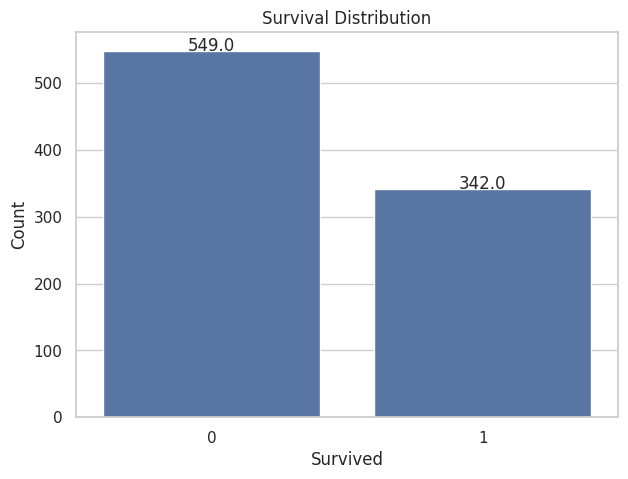

In [8]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='Survived',
    data=df
)

for p in ax.patches:
    ax.annotate(
        str(p.get_height()),
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha='center'
    )

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

### Observation

The number of passengers who did not survive was higher than the number of passengers who survived.

# Gender Distribution

This chart shows the distribution of male and female passengers.

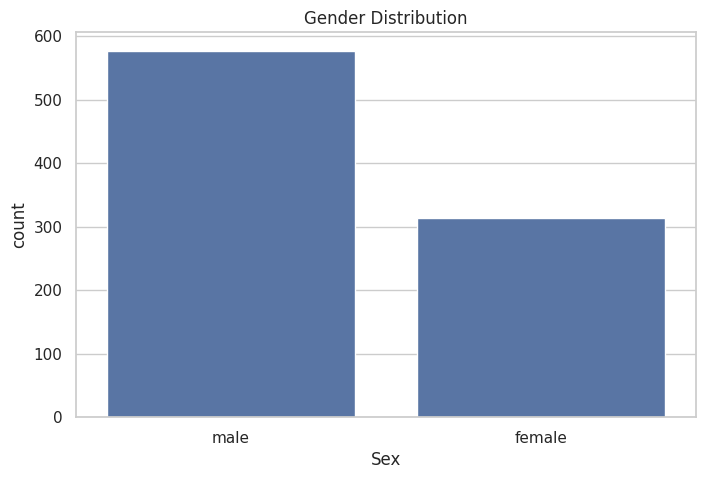

In [9]:
sns.countplot(
    x='Sex',
    data=df
)

plt.title("Gender Distribution")

plt.show()

### Observation

The Titanic carried more male passengers than female passengers.

# Survival by Gender

This visualization examines the relationship between gender and survival.


Here 0=not survived
1=survived

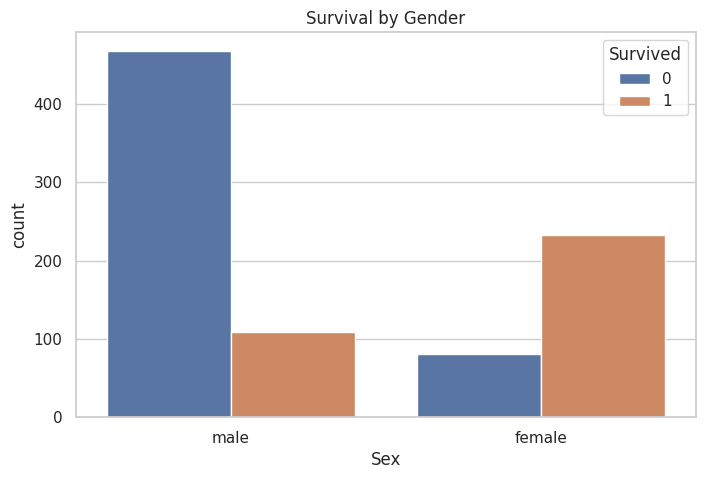

In [10]:
sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival by Gender")

plt.show()

### Observation

Female passengers had a significantly higher survival rate compared to male passengers.

# Age Distribution

The age distribution of passengers is visualized using a histogram.

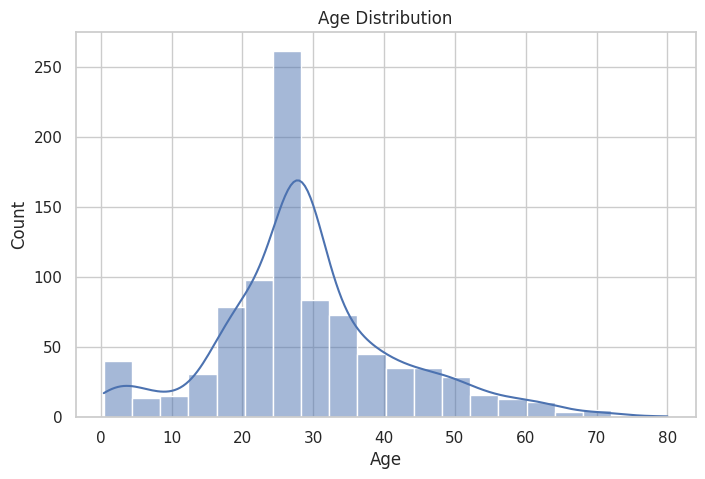

In [11]:
sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

### Observation

Most passengers were between 20 and 40 years old.

# Passenger Class vs Survival

This analysis investigates how passenger class affected survival rates.

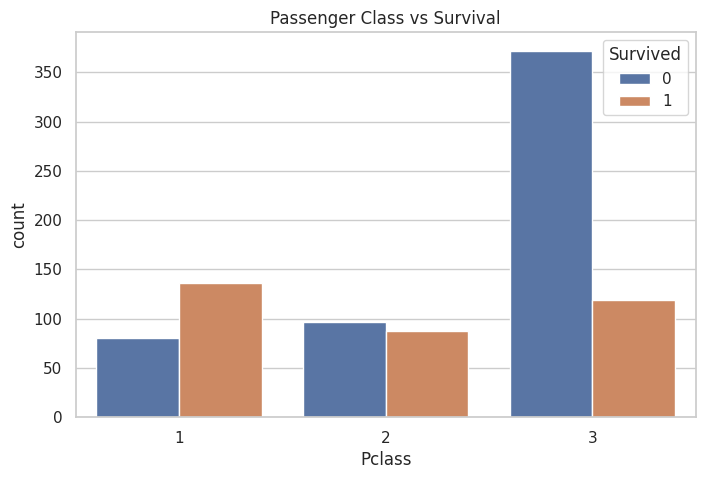

In [12]:
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Passenger Class vs Survival")

plt.show()

### Observation

Passengers travelling in First Class had higher survival rates than those in Second and Third Class.

# Fare Distribution

Ticket fare distribution is examined to understand passenger spending patterns.

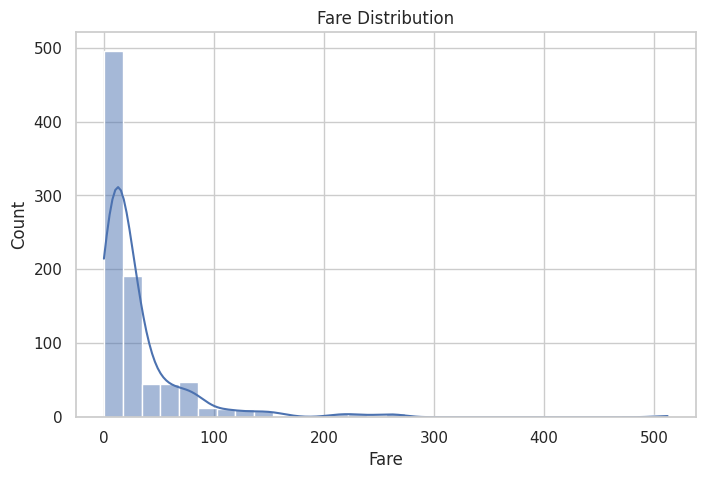

In [13]:
sns.histplot(
    data=df,
    x='Fare',
    bins=30,
    kde=True
)

plt.title("Fare Distribution")

plt.show()

### Observation

Most passengers paid lower fares, while a small number paid significantly higher fares.

# Fare vs Survival

This boxplot analyzes whether fare had an impact on survival.

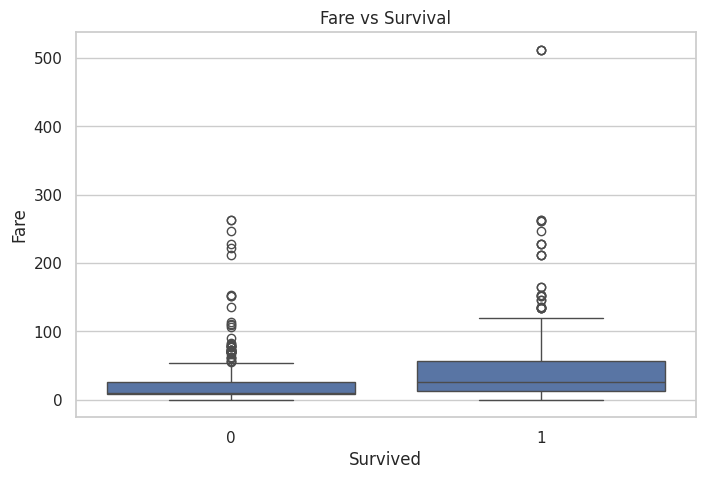

In [15]:
sns.boxplot(
    x='Survived',
    y='Fare',
    data=df
)

plt.title("Fare vs Survival")

plt.show()

### Observation

Passengers who survived generally paid higher fares than those who did not survive.

# Correlation Analysis

A correlation heatmap is used to identify relationships among numerical variables.

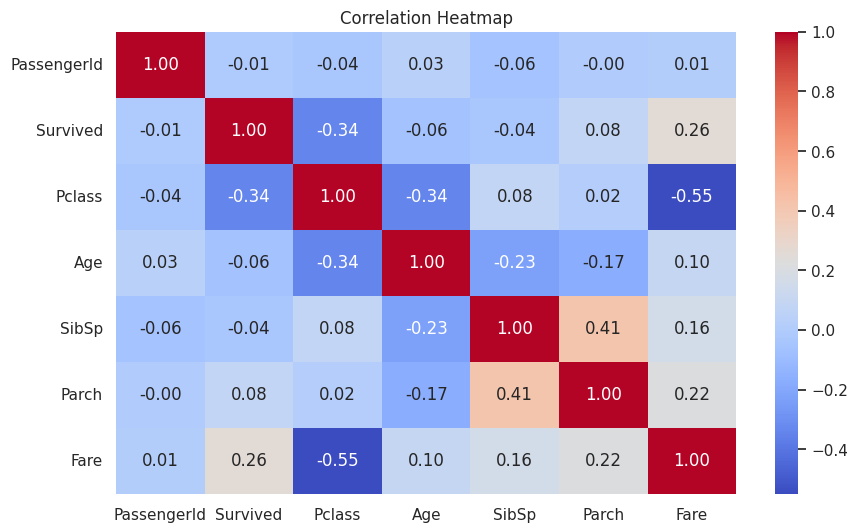

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

Passenger class, fare, and survival show meaningful relationships. Strong correlations help identify factors that influenced survival outcomes.

# Conclusion

The Titanic dataset was successfully cleaned and analyzed using exploratory data analysis techniques.

## Key Findings

1. More passengers died than survived.
2. Female passengers had significantly higher survival rates than males.
3. First-class passengers were more likely to survive.
4. Most passengers were between 20 and 40 years old.
5. Higher ticket fares were associated with higher survival chances.
6. Passenger class and fare were important factors influencing survival.

This analysis demonstrates how data cleaning and EDA can be used to uncover meaningful insights and trends from real-world datasets.